   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  2010-02-05        42.31       2.572        NaN        NaN   
1      1  2010-02-12        38.51       2.548        NaN        NaN   
2      1  2010-02-19        39.93       2.514        NaN        NaN   
3      1  2010-02-26        46.63       2.561        NaN        NaN   
4      1  2010-03-05        46.50       2.625        NaN        NaN   

   MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  IsHoliday  
0        NaN        NaN        NaN  211.096358         8.106      False  
1        NaN        NaN        NaN  211.242170         8.106       True  
2        NaN        NaN        NaN  211.289143         8.106      False  
3        NaN        NaN        NaN  211.319643         8.106      False  
4        NaN        NaN        NaN  211.350143         8.106      False  
   Store Type    Size
0      1    A  151315
1      2    A  202307
2      3    B   37392
3      4    A  205863
4      5    B   348

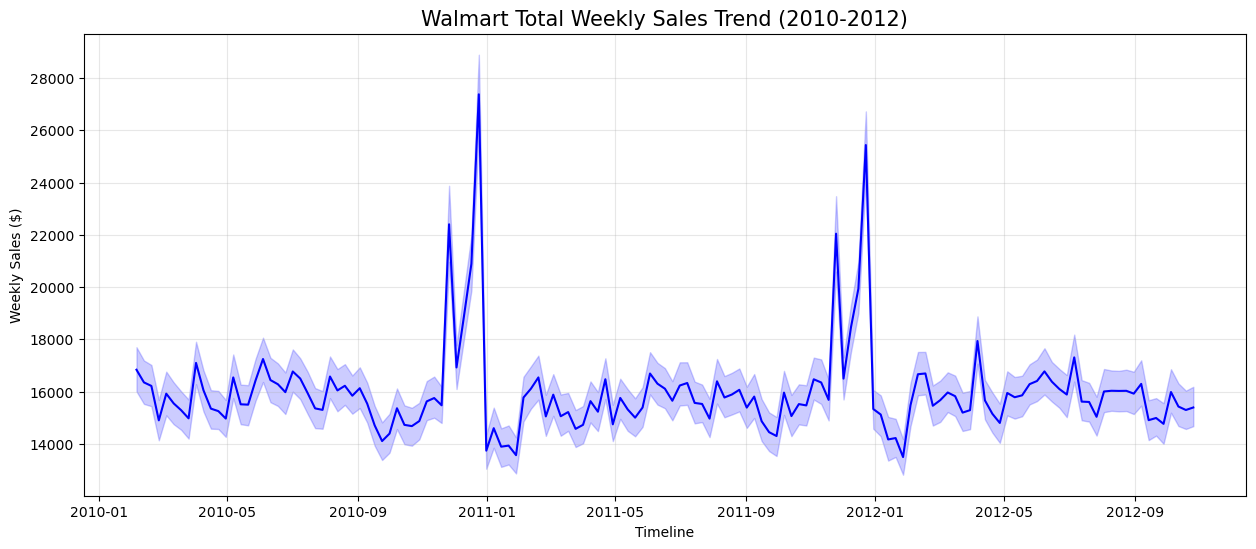

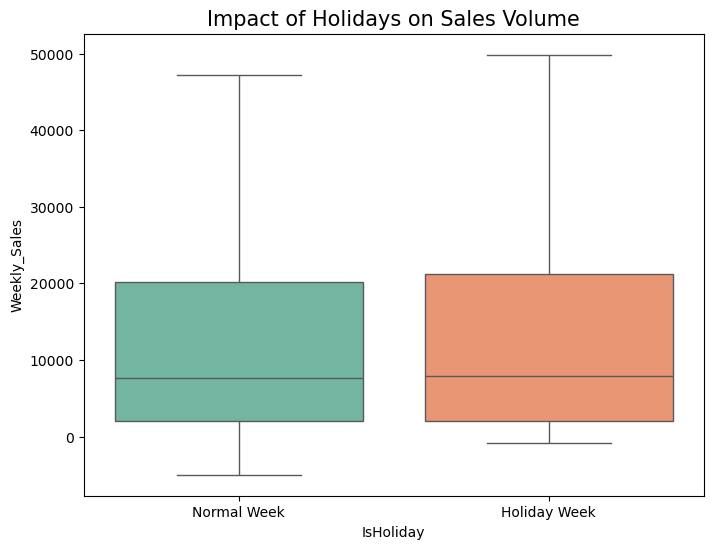

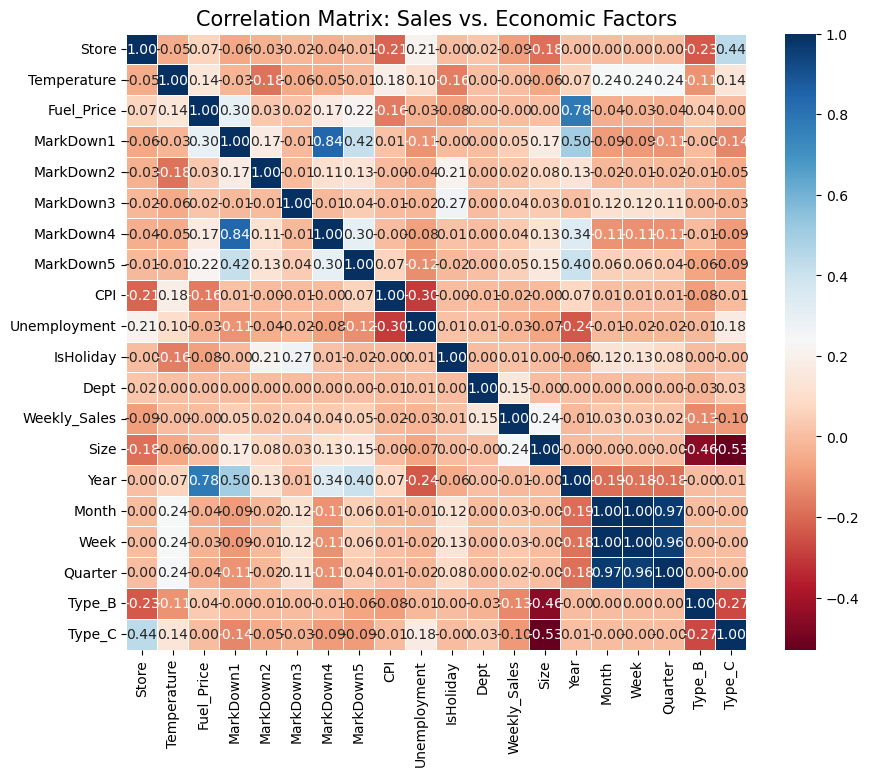

Lag features successfully created!
      Store  Dept       Date  Weekly_Sales  Sales_Lag_1
3729      1     1 2011-02-04      21665.76     18461.18
3800      1     1 2011-02-11      37887.17     21665.76
3872      1     1 2011-02-18      46845.87     37887.17
3944      1     1 2011-02-25      19363.83     46845.87
4016      1     1 2011-03-04      20327.61     19363.83
4089      1     1 2011-03-11      21280.40     20327.61
4163      1     1 2011-03-18      20334.23     21280.40
4235      1     1 2011-03-25      20881.10     20334.23
4306      1     1 2011-04-01      20398.09     20881.10
4377      1     1 2011-04-08      23873.79     20398.09
                            OLS Regression Results                            
Dep. Variable:           Weekly_Sales   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                 8.116e+05
Date:                Thu, 26 Mar 

In [1]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

import numpy as np
import pandas as pd
# load datasets for analysis 
features = pd.read_csv(r"C:\Users\payal\OneDrive\Documents\Projects\Walmart_Sales_Analysis\Data\features.csv.zip", compression='zip')
stores = pd.read_csv(r"C:\Users\payal\OneDrive\Documents\Projects\Walmart_Sales_Analysis\Data\stores.csv")
train = pd.read_csv(r"C:\Users\payal\OneDrive\Documents\Projects\Walmart_Sales_Analysis\Data\train.csv.zip", compression ='zip')
print(features.head()) 
print(stores.head())
print(train.head())

#  marging the datasets 
print("data merged ---------------------------------------------------------------------------------------------------------------")
data_merged = pd.merge(features , train , on= ["Store","Date","IsHoliday"] , how= "inner")
print(data_merged)
print("final merge----------------------------------------------------------------------------------------------------------------")
final_merge = pd.merge(data_merged, stores, on= "Store" , how= "inner")
print(final_merge)

# Data Wrangling or Preprocessing.
# data type conversion
final_merge['Date'] = pd.to_datetime(final_merge['Date'])

# handling null values
final_merge.fillna(0, inplace= True)
print(f"sum of total null values {final_merge.isnull().sum().sum()}")

# removing duplicates 
# Step 1: Count the mess
print(f"Duplicates found: {final_merge.duplicated().sum()}")
# Step 2: Clean the mess permanently
final_merge.drop_duplicates(inplace=True)
# Step 3: Verify the clean-up
print(f"Duplicates after cleaning: {final_merge.duplicated().sum()}")

# final verification
print(f"shape of the data is : {final_merge.shape}")
print(f" data types : {final_merge.info()}")
print(f"summary : {final_merge.describe()}")


# Feature Engineering

# 1. TIME INTELLIGENCE
print("\n--- Starting Feature Engineering ---")

# Extracting basic time components
final_merge['Year'] = final_merge['Date'].dt.year
final_merge['Month'] = final_merge['Date'].dt.month

# IMPROVEMENT 1: Added .astype(int) to prevent library crashes later
final_merge['Week'] = final_merge['Date'].dt.isocalendar().week.astype(int)

# Optional but recommended: Quarter (1-4)
final_merge['Quarter'] = final_merge['Date'].dt.quarter

print("Time features extracted successfully.")

# Visualizing the newly engineered time features
print("\n--- Extracted Time Features Preview ---")
print(final_merge[['Date', 'Year', 'Month', 'Week', 'Quarter']].head(10))

# 2. ENCODING ISHOLIDAY
print("\n--- Encoding Categorical Variables ---")
# Converting True/False to 1/0
final_merge['IsHoliday'] = final_merge['IsHoliday'].astype(int)
print("IsHoliday successfully converted to binary.")

# 3. ENCODING TYPE (One-Hot Encoding)
# IMPROVEMENT 2: Added drop_first=True to avoid the Dummy Variable Trap!
final_merge = pd.get_dummies(final_merge, columns=['Type'], drop_first=True, dtype=int)

print("Store Type successfully one-hot encoded.")

# Let's verify the changes (Note: Type_A is now hidden as the baseline!)
print("\n--- Categorical Encoding Preview ---")
# We use .columns to automatically find whatever Type_ columns were kept
type_cols = [col for col in final_merge.columns if 'Type_' in col]
print(final_merge[['Store', 'IsHoliday'] + type_cols].head())



# Saving the cleaned dataset for GitHub and Power BI
final_merge.to_csv(r"C:\Users\payal\OneDrive\Documents\Projects\Walmart_Sales_Analysis\Data\cleaned_walmart_sales.csv", index=False)

print("File saved successfully in your Data folder!")




# 1. The Seasonality Trend (Line Plot)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Grouping data by Date to see the total sales across all stores
plt.figure(figsize=(15, 6))
sns.lineplot(data=final_merge, x='Date', y='Weekly_Sales', color='blue')
plt.title('Walmart Total Weekly Sales Trend (2010-2012)', fontsize=15)
plt.xlabel('Timeline')
plt.ylabel('Weekly Sales ($)')
plt.grid(True, alpha=0.3)
plt.show()

 # The Holiday Impact (Boxplot)
# 2. Comparing Sales: Holiday vs. Non-Holiday
plt.figure(figsize=(8, 6))
# Updated to follow the new Seaborn standards
sns.boxplot(
    data=final_merge, 
    x='IsHoliday', 
    y='Weekly_Sales', 
    hue='IsHoliday',    # <--- Added this to link color to the X-axis
    palette='Set2', 
    showfliers=False, 
    legend=False        # <--- Added this to hide the redundant legend
)
plt.title('Impact of Holidays on Sales Volume', fontsize=15)
plt.xticks([0, 1], ['Normal Week', 'Holiday Week'])
plt.show()

# The Correlation Heatmap
# 3. Correlation Heatmap
plt.figure(figsize=(10, 8))
# We select only numeric columns for correlation
numeric_cols = final_merge.select_dtypes(include=['float64', 'int64', 'int32']).columns
corr = final_merge[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='RdBu', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: Sales vs. Economic Factors', fontsize=15)
plt.show()

# Lag Features in your Walmart project
# 1. Sort data by Date to ensure the 'shift' moves in the right chronological order
final_merge = final_merge.sort_values(by=['Store', 'Dept', 'Date'])

# 2. Create a 1-Week Lag (Sales from the previous week)
final_merge['Sales_Lag_1'] = final_merge.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)

# 3. Create a 1-Month Lag (Sales from 4 weeks ago)
final_merge['Sales_Lag_4'] = final_merge.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(4)

# 4. Create a 1-Year Lag (Sales from 52 weeks ago - Best for Seasonality!)
final_merge['Sales_Lag_52'] = final_merge.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(52)

# 5. Handle the NaN values created by shifting
final_merge.dropna(inplace=True)

print("Lag features successfully created!")
print(final_merge[['Store', 'Dept', 'Date', 'Weekly_Sales', 'Sales_Lag_1']].head(10))



from sklearn.metrics import mean_squared_error, r2_score

# 1. Define your Features (X) and your Target (y)
# We exclude 'Date' and 'Weekly_Sales' from X
features = ['IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 
            'Sales_Lag_1', 'Sales_Lag_52', 'Type_B', 'Type_C']
X = final_merge[features]
y = final_merge['Weekly_Sales']

# 2. Time-Based Split (Last 20% of data for testing)
split_point = int(len(final_merge) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

# 3. Add a constant (Intercept) to the features
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# 4. Train the OLS Model
model = sm.OLS(y_train, X_train_sm).fit()

# 5. Display the Results
print(model.summary())